ライブラリのインポート

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV # ハイパーパラメータを探索するためのGridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error # 回帰モデルの性能を評価するための関数

設定値の入力

In [37]:
dataset_file_name = "Material_Lifespan_Dataset_encoded_sklearn.csv"
number_of_test_samples = 150 # テストデータとして使うサンプル数を指定
fold_number = 5 # クロスバリデーションの分割数を指定(5分割)
svr_cs = 2 ** np.arange(-5, 11, dtype=float) # SVRのCの候補を作成, C:誤差をどれくらい厳しく小さくするか決める値
svr_epsilons = 2 ** np.arange(-10, 1, dtype=float) # SVRのepsilonの候補を作成, epsilon:誤差の許容範囲を決める値(ε-チューブ)
svr_gammas = 2 ** np.arange(-20, 11, dtype=float) # SVRのgammaの候補を作成, gamma:RBFカーネルで1つ1つのデータがどれくらい影響するか決める値

γを最初に決めるための関数

In [38]:
# グラム行列の分散が最大になるgammaを選ぶ関数を定義します。
def gamma_optimization_with_variance(autoscaled_x, gamma_candidates):
    x_array = autoscaled_x.to_numpy() # pandasのDataFrameをnumpy配列に変換
    variance_of_gram_matrix = [] # gammaごとのグラム行列の分散を入れるリストを作成
    for gamma in gamma_candidates: # gammaの候補を1つずつ取り出して計算
        difference = x_array[:, np.newaxis, :] - x_array[np.newaxis, :, :] # 各サンプル同士の差を計算
        squared_distance = np.sum(difference ** 2, axis=2) # 各サンプル同士の距離の2乗を計算
        gram_matrix = np.exp(-gamma * squared_distance) # RBFカーネルの式を使ってグラム行列を計算
        variance_of_gram_matrix.append(gram_matrix.var(ddof=1)) # グラム行列の分散を計算してリストに追加
    best_index = np.argmax(variance_of_gram_matrix) # 分散が最大になった場所の番号を取得
    optimal_gamma = gamma_candidates[best_index] # 分散が最大になったgammaを取り出す
    return optimal_gamma # 最適なgammaを返す

評価指標を表示するための関数

In [39]:
# R2、RMSE、MAEを計算して表示する関数を定義します。
def calculate_and_print_metrics(y_true, y_predicted, data_name):
    r2 = r2_score(y_true, y_predicted) # R2を計算
    mse = mean_squared_error(y_true, y_predicted) # MSEを計算
    rmse = np.sqrt(mse) # MSEの平方根を取ってRMSEを計算
    mae = mean_absolute_error(y_true, y_predicted) # MAEを計算
    
    print(f"\n{data_name} data") # データの種類を表示
    print(f"R2   : {r2:.3f}") # R2を小数第3位まで表示
    print(f"RMSE : {rmse:.3f}") # RMSEを小数第3位まで表示
    print(f"MAE  : {mae:.3f}") # MAEを小数第3位まで表示

実測値と予測値の散布図を作成

In [40]:
def show_actual_vs_predicted_plot(y_true, y_predicted, data_name):
    plt.figure(figsize=(6, 6)) # グラフのサイズを指定
    plt.scatter(y_true, y_predicted, alpha=0.7) # 実測値を横軸、予測値を縦軸にして散布図を作成
    min_value = min(y_true.min(), y_predicted.min()) # 実測値と予測値の中で最小値を取得
    max_value = max(y_true.max(), y_predicted.max()) # 実測値と予測値の中で最大値を取得
    plt.plot([min_value, max_value], [min_value, max_value], color="red") # 予測が完全に正しければ乗る対角線を描く
    plt.xlabel("Actual PredictedHours")
    plt.ylabel("Estimated PredictedHours")
    plt.title(f"Actual vs. Estimated ({data_name} data)") 
    plt.grid(True) 
    plt.tight_layout() 
    plt.show()

CSVファイルの読み込み

In [41]:
dataset = pd.read_csv(dataset_file_name)
print("Dataset shape:", dataset.shape) # データの行数と列数を表示
print("Columns:", list(dataset.columns)) # データの列名を表示

Dataset shape: (1000, 24)
Columns: ['PredictedHours', 'CoolRate', 'QuenchDuration', 'ForgeDuration', 'HeatProcessTime', 'NickelComposition', 'IronComposition', 'CobaltComposition', 'ChromiumComposition', 'MinorDefects', 'MajorDefects', 'EdgeDefects', 'ComponentType_Blade', 'ComponentType_Block', 'ComponentType_Nozzle', 'ComponentType_Valve', 'StructureType_colGrain', 'StructureType_equiGrain', 'StructureType_singleGrain', 'InitialPosition_Bottom', 'InitialPosition_Top', 'FormationMethod_Continuous', 'FormationMethod_Die', 'FormationMethod_Investment']


説明変数xと目的変数yに分ける

In [42]:
# 説明変数xとして、PredictedHours以外の列を取り出す
x = dataset.drop(columns=["PredictedHours"])
# 目的変数yとして、予測したいPredictedHoursの列を取り出す
y = dataset["PredictedHours"]

学習データとテストデータに分割

In [43]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=number_of_test_samples,
    random_state=0,
)

オートスケーリング

In [44]:
# 学習データの説明変数を平均0、標準偏差1に変換
autoscaled_x_train = (x_train - x_train.mean(axis=0)) / x_train.std(axis=0, ddof=1)
# 学習データの目的変数も平均0、標準偏差1に変換
autoscaled_y_train = (y_train - y_train.mean()) / y_train.std(ddof=1)
# テストデータの説明変数を、学習データの平均と標準偏差を使って変換
autoscaled_x_test = (x_test - x_train.mean(axis=0)) / x_train.std(axis=0, ddof=1)

γの最初の最適化

In [45]:
# グラム行列の分散が最大になるgammaを選択
optimal_svr_gamma = gamma_optimization_with_variance(autoscaled_x_train, svr_gammas)

εの最適化

In [46]:
# Cとgammaを固定して、εだけをGridSearchCVで探索
model_in_cv = GridSearchCV(
    svm.SVR(kernel="rbf", C=3, gamma=optimal_svr_gamma),
    {"epsilon": svr_epsilons},
    cv=fold_number,
)
model_in_cv.fit(autoscaled_x_train, autoscaled_y_train) # 学習データを使ってεの探索を実行
optimal_svr_epsilon = model_in_cv.best_params_["epsilon"] # 最も良かったεを取り出す

Cの最適化

In [47]:
# εとγを固定して、CだけをGridSearchCVで探索
model_in_cv = GridSearchCV(
    svm.SVR(
        kernel="rbf",
        epsilon=optimal_svr_epsilon,
        gamma=optimal_svr_gamma,
    ),
    {"C": svr_cs},
    cv=fold_number,
)
model_in_cv.fit(autoscaled_x_train, autoscaled_y_train) # 学習データを使ってCの探索を実行
optimal_svr_c = model_in_cv.best_params_["C"] # 最も良かったCを取り出す

γの再最適化

In [48]:
# εとCを固定して、γをGridSearchCVでもう一度探索
model_in_cv = GridSearchCV(
    svm.SVR(
        kernel="rbf",
        epsilon=optimal_svr_epsilon,
        C=optimal_svr_c,
    ),
    {"gamma": svr_gammas},
    cv=fold_number,
)

model_in_cv.fit(autoscaled_x_train, autoscaled_y_train) # 学習データを使ってγの探索を実行
optimal_svr_gamma = model_in_cv.best_params_["gamma"] # 最も良かったγを取り出す
print("C       :", optimal_svr_c) # 最適化されたCを表示
print("epsilon :", optimal_svr_epsilon) # 最適化されたεを表示
print("gamma   :", optimal_svr_gamma) # 最適化されたγを表示

C       : 4.0
epsilon : 0.0625
gamma   : 0.03125


SVRモデルの作成と学習

In [49]:
# 最適化されたC、ε、γを使ってSVRモデルを作成
model = svm.SVR(
    kernel="rbf",
    C=optimal_svr_c,
    epsilon=optimal_svr_epsilon,
    gamma=optimal_svr_gamma,
)
model.fit(autoscaled_x_train, autoscaled_y_train) # オートスケーリング済みの学習データでSVRモデルを学習

SVR(C=np.float64(4.0), epsilon=np.float64(0.0625), gamma=np.float64(0.03125))

学習データとテストデータを予測

In [50]:
# 学習データについて、オートスケーリングされたyの値を予測
autoscaled_y_train_predicted = model.predict(autoscaled_x_train)
# テストデータについて、オートスケーリングされたyの値を予測
autoscaled_y_test_predicted = model.predict(autoscaled_x_test)
# 学習データの予測値を、元のPredictedHoursの単位に戻す
y_train_predicted = autoscaled_y_train_predicted * y_train.std(ddof=1) + y_train.mean()
# テストデータの予測値を、元のPredictedHoursの単位に戻す
y_test_predicted = autoscaled_y_test_predicted * y_train.std(ddof=1) + y_train.mean()

モデルの性能を確認

In [51]:
# 学習データのR2、RMSE、MAEを表示
calculate_and_print_metrics(y_train, y_train_predicted, "Training")
# テストデータのR2、RMSE、MAEを表示
calculate_and_print_metrics(y_test, y_test_predicted, "Test")


Training data
R2   : 0.929
RMSE : 90.249
MAE  : 55.574

Test data
R2   : 0.716
RMSE : 187.951
MAE  : 149.213


予測値-実測値プロットを表示

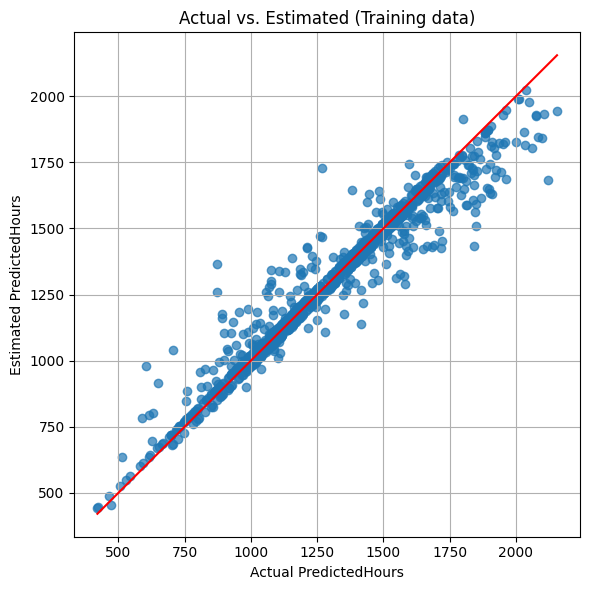

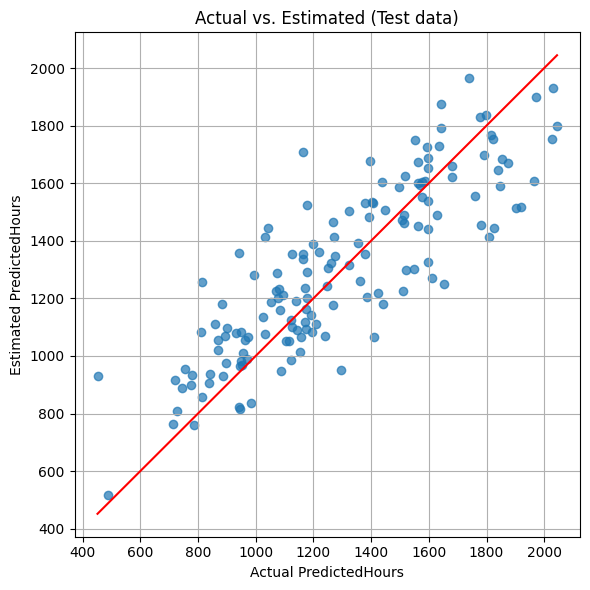

In [52]:
# 学習データの予測値-実測値プロット
show_actual_vs_predicted_plot(
    y_train,
    y_train_predicted,
    "Training",
)
# テストデータの予測値-実測値プロット
show_actual_vs_predicted_plot(
    y_test,
    y_test_predicted,
    "Test",
)

予測結果を表示

In [53]:
# 学習データの予測値と実測値をDataFrameにまとめる
train_results = pd.DataFrame(
    {
        "Actual_PredictedHours": y_train,
        "Estimated_PredictedHours": y_train_predicted,
    }
)
# テストデータの予測値と実測値をDataFrameにまとめる
test_results = pd.DataFrame(
    {
        "Actual_PredictedHours": y_test,
        "Estimated_PredictedHours": y_test_predicted,
    }
)
# 学習データの予測結果を表示
print("\nTraining data prediction results")
# 学習データの予測結果の先頭10行を表示
print(train_results.head(10))
# テストデータの予測結果を表示
print("\nTest data prediction results")
# テストデータの予測結果の先頭10行を表示
print(test_results.head(10))


Training data prediction results
     Actual_PredictedHours  Estimated_PredictedHours
271               1520.389               1499.189728
30                1533.920               1555.020825
403               1104.456               1070.673946
757               1675.369               1696.591092
975               1715.460               1657.951524
990               1175.644               1154.408303
457               1030.257               1009.035970
362               1259.184               1472.071839
860               1250.704               1153.661657
483                796.755                818.031350

Test data prediction results
     Actual_PredictedHours  Estimated_PredictedHours
993               1269.465               1464.393828
859               1127.645               1100.686685
298               1518.407               1624.221771
553               1094.772               1211.823340
672               1054.217               1187.407705
971               1653.343         